# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture
**Project Theme:** Seasonal Agriculture Performance
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal
Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.



## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.



## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`



In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# Load the dataset

import os
file_path = "seasonal_agriculture_performance_dataset.csv" if os.path.exists("seasonal_agriculture_performance_dataset.csv") else "/content/seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Initial Data Understanding

In [3]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [4]:
# Top 5 rows

df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [5]:
# Bottom 5 rows

df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [6]:
# Random sample of records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [7]:
# Column names

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [8]:
# Data types and non-null counts

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [9]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
<StringArray>
['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007',
 'SF10008', 'SF10009', 'SF10010', 'SF10011', 'SF10012', 'SF10013', 'SF10014',
 'SF10015', 'SF10016', 'SF10017', 'SF10018', 'SF10019', 'SF10020']
Length: 20, dtype: str

State:
8 unique values
<StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str

District:
10 unique values
<StringArray>
[  'Rajkot', 'Nalgonda', 'Warangal',   'Indore', 'Ludhiana',  'Raichur',
   'Guntur',  'Krishna',   'Nashik',    'Erode']
Length: 10, dtype: str

Crop:
8 unique values
<StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

Season:
3 unique values
<StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

Irrigation_Method:
4 unique values
<StringArray>
['Drip', 'Flood

/tmp/ipykernel_161/297702048.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [10]:
# Numerical summary statistics

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [11]:
# Categorical summary

df.describe(include="object")

/tmp/ipykernel_161/2001505984.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5. Data Quality Analysis

Before performing analysis, investigate missing values, duplicates, data types and unusual values.

Explain what you observe and justify each cleaning decision.

In [12]:
# Missing values

missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


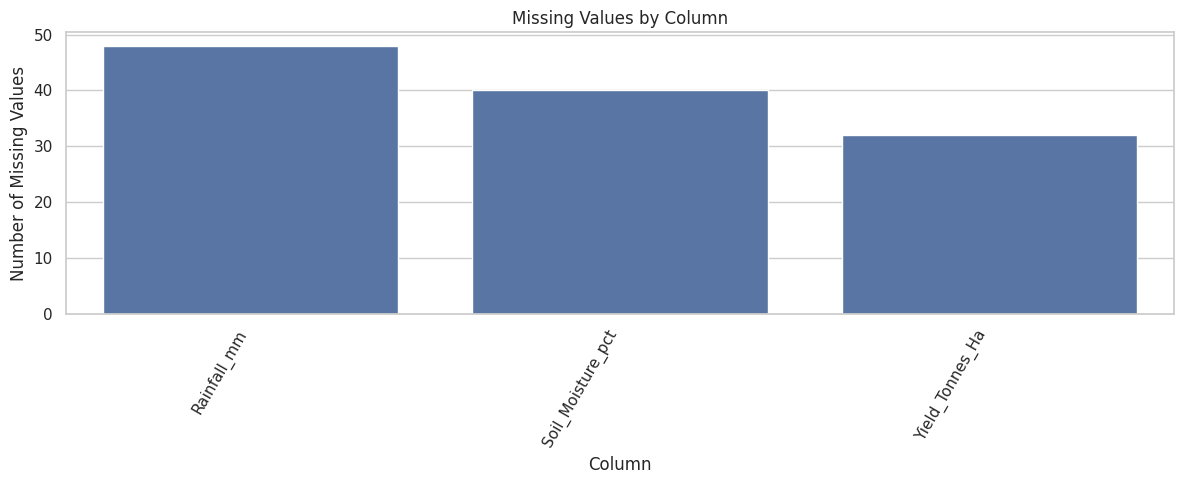

In [13]:
# Visualize missing values

plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [14]:
# Duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [15]:
# Remove duplicate rows (if any)

df = df.drop_duplicates()
print("Rows after duplicate removal:", df.shape[0])

Rows after duplicate removal: 4000


**Observation:**
- `Rainfall_mm` has 48 missing values (1.20%), `Soil_Moisture_pct` has 40 missing values (1.00%), and `Yield_Tonnes_Ha` has 32 missing values (0.80%). All other columns are fully populated.
- No duplicate rows were found (`df.duplicated().sum() = 0`), so no records needed to be dropped for that reason.
- Unique-value counts look sensible: 8 States, 10 Districts, 8 Crops, 3 Seasons (Kharif, Rabi, Zaid) and 4 Irrigation Methods (Drip, Flood, Rainfed, Sprinkler) - no unexpected or misspelled categories were found.

### Missing Value Treatment

Choose an appropriate strategy based on the nature of each variable.

Possible approaches:
- Remove records only when justified.
- Fill numerical values using an appropriate statistic when appropriate.
- Fill categorical values using a suitable category or method.
- Clearly document why the chosen approach is reasonable.

Do not blindly replace every missing value with zero.

In [16]:
# Yield = Production / Farm Area in every recorded row, so recompute it exactly
check = (df["Production_Tonnes"] / df["Farm_Area_Hectares"] - df["Yield_Tonnes_Ha"]).abs().max()
print("Max difference between recomputed and recorded yield:", round(check, 3))
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna((df["Production_Tonnes"] / df["Farm_Area_Hectares"]).round(2))

# Rainfall and soil moisture differ strongly by season, so fill with the season median
for col in ["Rainfall_mm", "Soil_Moisture_pct"]:
    df[col] = df[col].fillna(df.groupby("Season")[col].transform("median"))

print("Remaining missing values:", df.isnull().sum().sum())

Max difference between recomputed and recorded yield: 0.01
Remaining missing values: 0


**Justification:**
Yield_Tonnes_Ha matches Production_Tonnes / Farm_Area_Hectares to within 0.01 in every recorded row, so the 32 missing yield values were recomputed from those two columns instead of estimated. Rainfall and soil moisture differ strongly by season, so each missing value is filled with the median of its own season instead of one overall median. Missing values were 0.8% to 1.2% per column.

## 6. Variable Understanding

The dataset variables can be grouped into:

- Identifier variables
- Categorical variables
- Numerical variables
- Environmental variables
- Operational variables
- Production/performance variables
- Economic variables

Explain which variables are most relevant to the seasonal-performance problem and why.

In [17]:
# Numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


/tmp/ipykernel_161/71681187.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


**Which variables matter most for the seasonal-performance problem:**
- **Season** is the grouping variable for the whole analysis.
- **Environmental variables** (`Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Sunlight_Hours_Day`, `Soil_pH`, `Soil_Moisture_pct`) explain *why* performance might differ season to season.
- **Operational variables** (`Irrigation_Method`, `Fertilizer_kg_ha`, `Pesticide_Litre_ha`, `Nitrogen/Phosphorus/Potassium_kg_ha`, `Seed_Quality_Score`) capture farming practices that can be adjusted by season.
- **Production/performance variables** (`Yield_Tonnes_Ha`, `Production_Tonnes`, `Water_Efficiency_t_per_1000m3`, `Disease_Pest_Risk_pct`) are the core outcomes being compared across seasons.
- **Economic variables** (`Total_Cost_INR`, `Revenue_INR`, `Profit_INR`, `Market_Price_INR_Tonne`) translate agricultural outcomes into the business result that ultimately matters to farmers.
- `Farm_ID`, `State` and `District` are identifiers/location context rather than performance measures, but are useful for grouping and are used in the additional regional analysis in Section 13.

## 7. Statistical Analysis

Perform descriptive statistical analysis to understand the distribution and variation of the data.

In [18]:
# Descriptive statistics

stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.71,288.43,80.00,370.43,581.00,836.12,"1,395.20","1,315.20",465.70
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.50,6.70,8.00,21.70,26.40,31.20,47.00,39.00,9.50
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [19]:
# Median and standard deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.71,581.00,288.43,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.50,26.40,6.70,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [20]:
# Seasonal descriptive summary

season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      852.11 854.75 181.57   
Rabi                 7.75   7.68 4.18      435.94 430.30 174.69   
Zaid                 8.09   8.09 4.16      299.12 283.30 152.56   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.20   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.05   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.17   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.20 5.02         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.86         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.09   1.66 12.83             41.49  11.08 121.90   
Zaid              4.63   1.45 11.28             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

**Interpretation:**
- **Yield_Tonnes_Ha**: overall mean ≈ 5.26 t/ha vs median ≈ 1.74 t/ha - the mean is pulled well above the median, confirming a strong right skew. This is driven by Sugarcane, whose yields (38-53 t/ha average by season) sit far above every other crop (all under 3 t/ha).
- **Profit_INR**: mean is positive (~₹1.12 lakh) but the median profit is +₹38,808 in Kharif, -₹3,187 in Rabi and -₹62,144 in Zaid, and the standard deviation is very large relative to the mean. Profit is highly variable and roughly half of all farm records (49.15%) report a loss.
- **Rainfall_mm**: Kharif shows a much higher mean (≈852 mm) than Rabi (≈436 mm) or Zaid (≈299 mm), consistent with Kharif being the monsoon-fed season; std within each season is also sizeable, showing rainfall is not uniform even within a season.

## 8. Univariate Analysis

Create and interpret suitable plots for:
- Important categorical variables
- Important numerical variables
- Seasonal distribution
- Production/performance distributions
- Economic distributions

The examples below are starting points. Students should add or modify plots based on their own analytical questions.

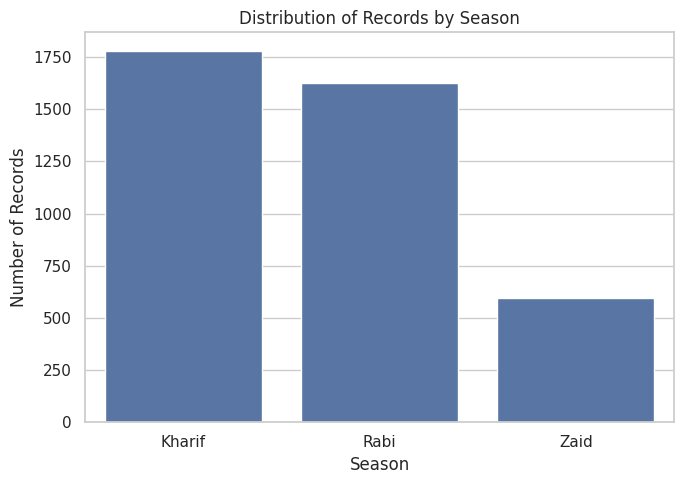

In [21]:
# Univariate: Season distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

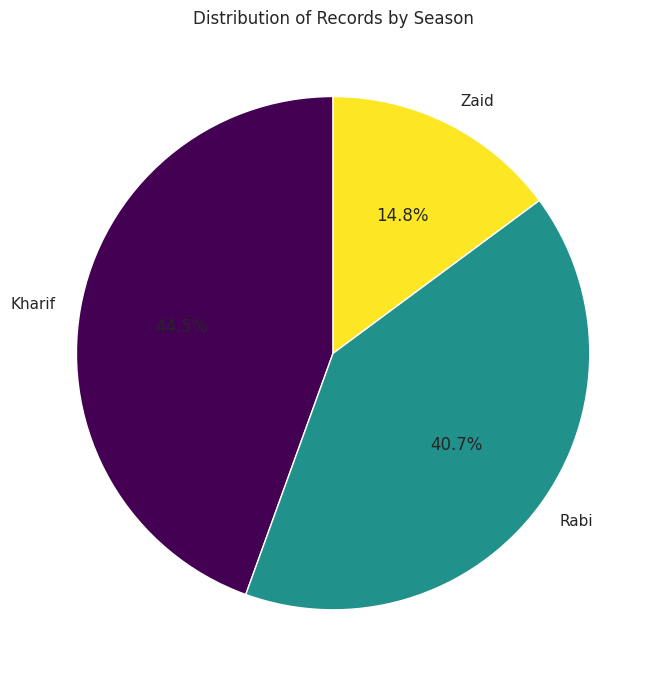

In [22]:
# Univariate: Season distribution (Pie Chart)

plt.figure(figsize=(7, 7))
df["Season"].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title("Distribution of Records by Season")
plt.ylabel("")  # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

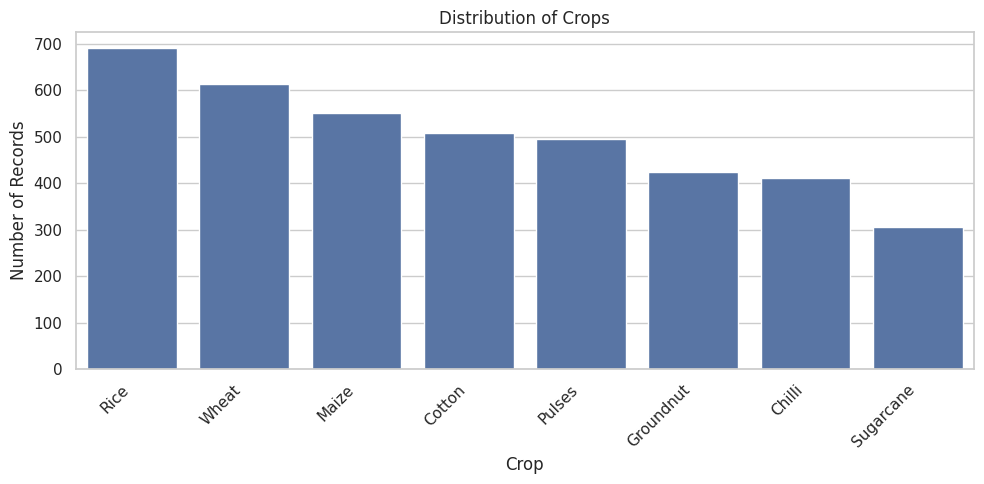

In [23]:
# Univariate: Crop distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

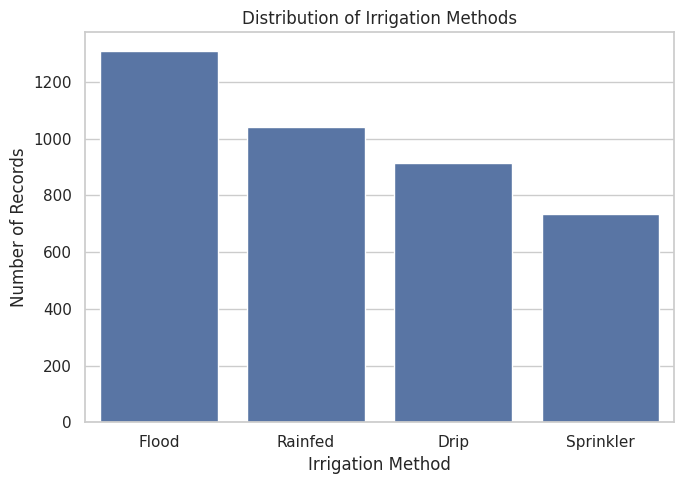

In [24]:
# Univariate: Irrigation method distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Irrigation_Method", order=df["Irrigation_Method"].value_counts().index)
plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

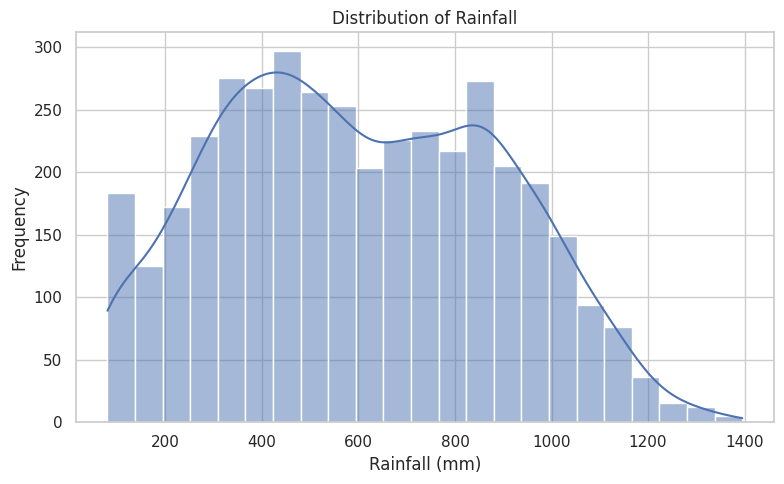

In [25]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

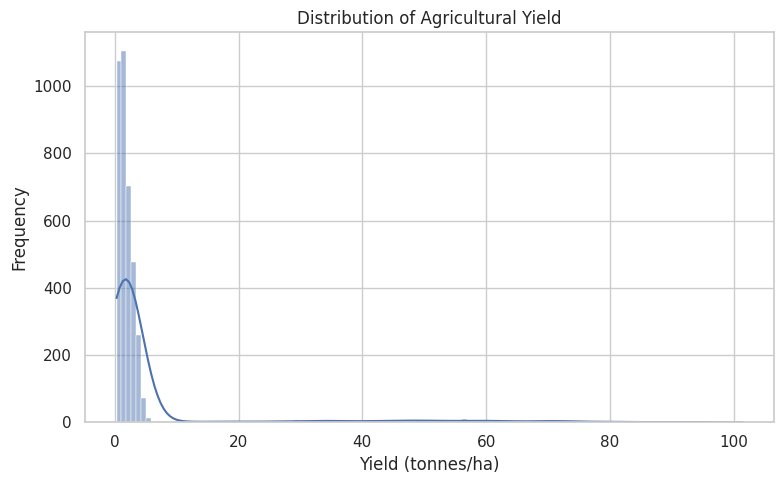

In [26]:
# Univariate: Yield distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

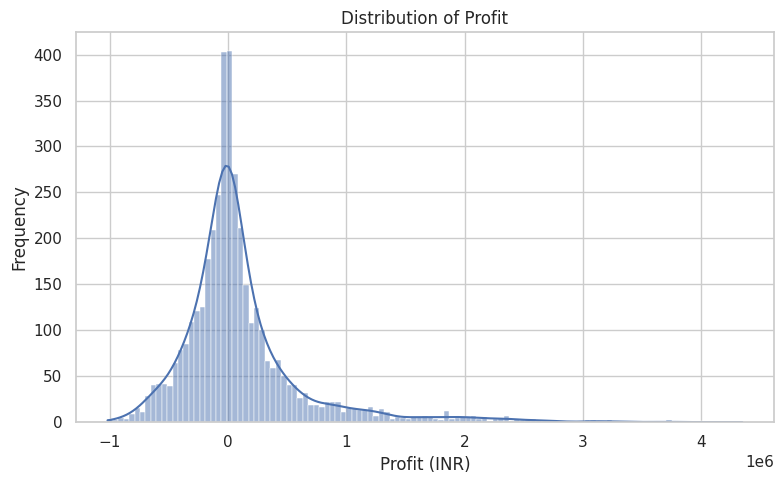

In [27]:
# Univariate: Profit distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

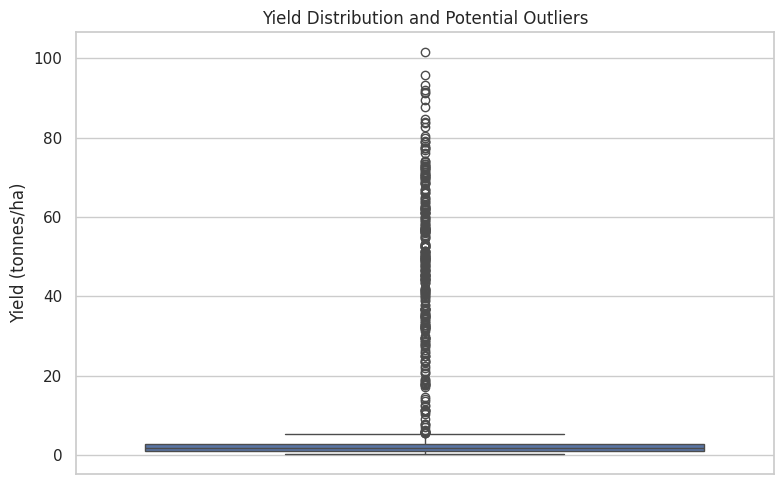

In [28]:
# Univariate: Boxplot for yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

**Interpretation:**
- **Rainfall** is roughly symmetric overall (skewness 0.14). Its spread reflects the three seasons, which have very different average rainfall (about 852, 436 and 299 mm).
- **Yield** is strongly right-skewed and clearly multi-modal - a large cluster under ~3 t/ha (most crops) and a small separate cluster above 20 t/ha (Sugarcane only), which is why the boxplot shows so many "outlier" points.
- **Profit** is right-skewed (skewness 2.4): a long tail of highly profitable farms on the right, while a large share of records sit below zero (49.15% report a loss), so both profitable and loss-making farms are common.
- **Rice** (690 records), **Wheat** (614) and **Maize** (551) are the most frequent crops; **Flood** (1,310 records) and **Rainfed** (1,041) are the most common irrigation methods, followed by Drip (915) and Sprinkler (734).

## 9. Outlier Analysis

Investigate potential outliers using statistical and visual methods.

Do not automatically delete outliers. Decide whether an extreme value is:
- A data-entry problem,
- A legitimate observation,
- Or something requiring further investigation.

In [29]:
# IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.63,5.52,304,7.60
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


In [30]:
# Investigate the Yield_Tonnes_Ha outliers specifically

df[df["Yield_Tonnes_Ha"] > 20][["Crop", "Season", "Yield_Tonnes_Ha"]].head(10)

,Crop,Season,Yield_Tonnes_Ha
47,Sugarcane,Zaid,36.69
75,Sugarcane,Kharif,62.58
79,Sugarcane,Zaid,33.55
82,Sugarcane,Rabi,49.52
92,Sugarcane,Kharif,70.23
113,Sugarcane,Rabi,58.06
132,Sugarcane,Kharif,29.47
154,Sugarcane,Kharif,47.88
155,Sugarcane,Kharif,62.09
164,Sugarcane,Rabi,36.91


**Decision:**
All 267 records with `Yield_Tonnes_Ha` > 20 belong to a single crop - **Sugarcane**. This is a legitimate agronomic fact (sugarcane yields are measured in tens of tonnes/ha, unlike grain crops measured in low single digits) and not a data-entry error, so these rows are **kept, not capped or removed**. However, they must be **excluded or analyzed separately** whenever yield is compared or averaged across all crops together (e.g. the overall `Yield_Tonnes_Ha` mean above is inflated by Sugarcane); crop-specific or crop-controlled comparisons (as done in Section 12's crop-season table) avoid this distortion.

## 10. Bivariate Analysis

Bivariate analysis examines relationships or differences between two variables.


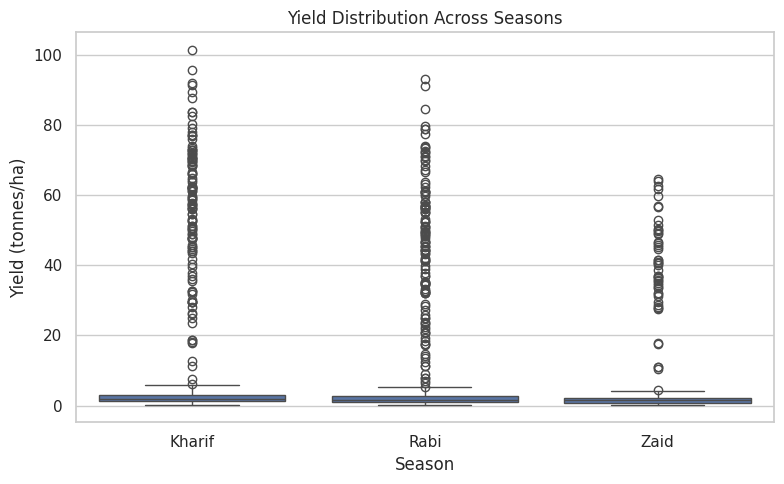

In [31]:
# Bivariate: Season vs Yield

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

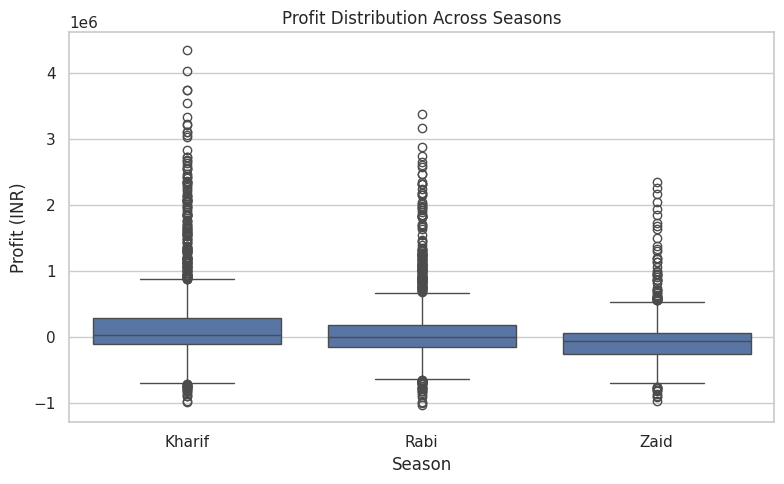

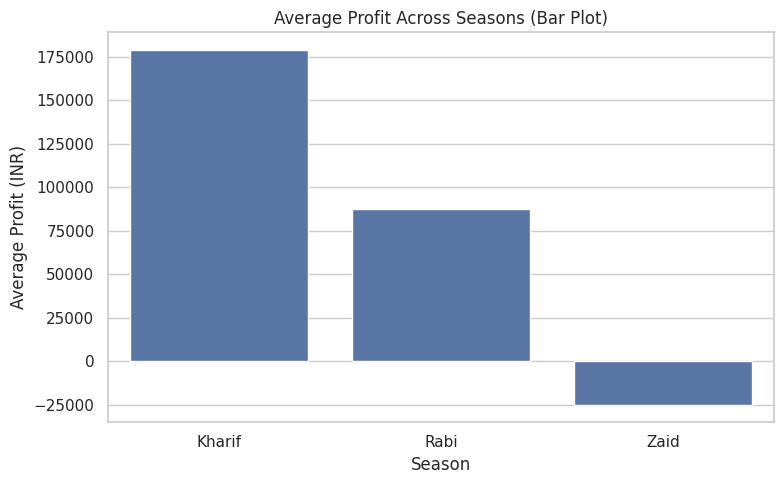

In [32]:
# Bivariate: Season vs Profit

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

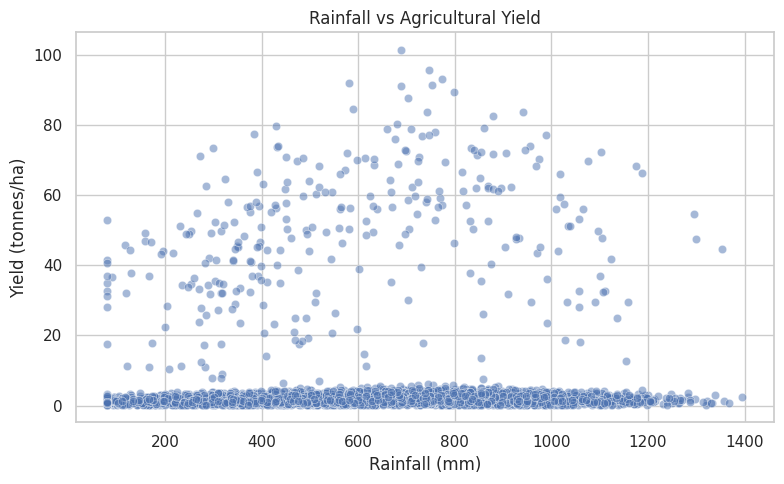

In [33]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

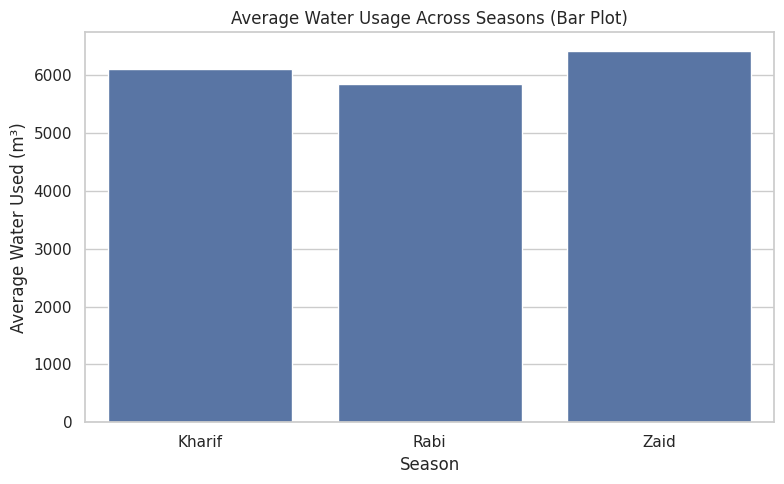

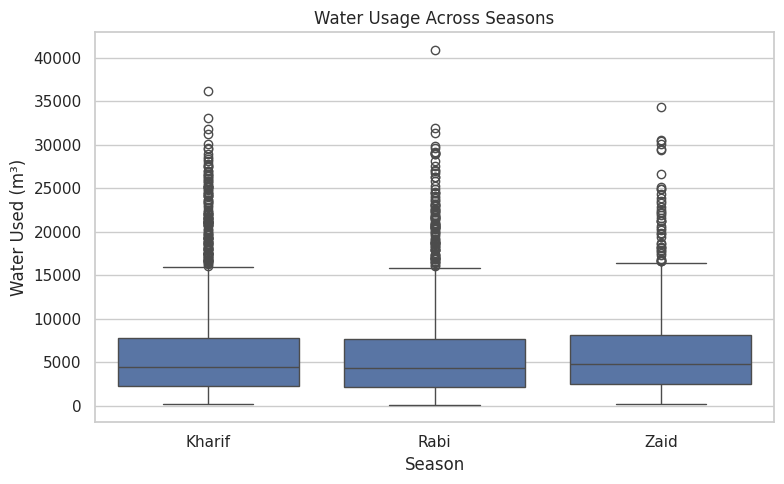

In [34]:
# Bivariate: Water usage across seasons

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar=None)
plt.title("Average Water Usage Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()

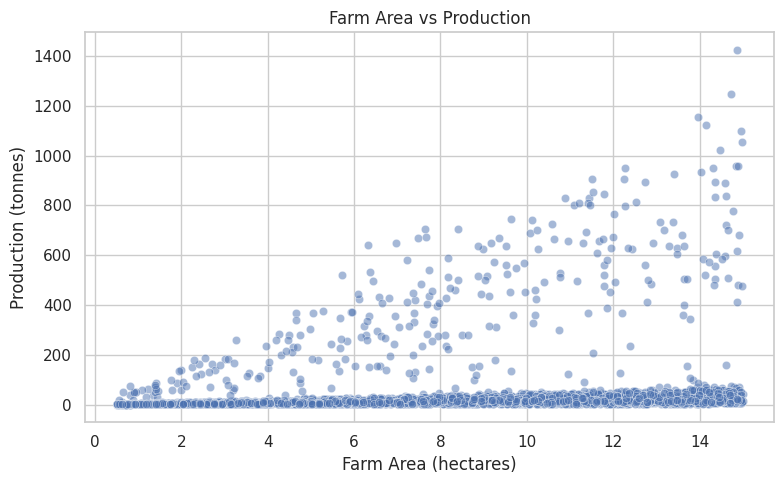

In [35]:
# Bivariate: Farm area vs Production

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

**Interpretation:**
- **Kharif** shows the highest median yield and profit of the three seasons (season averages: Kharif ₹1.79 lakh profit vs Rabi ₹0.88 lakh vs Zaid a **loss** of ₹24,805 on average), so Kharif is the strongest-performing season overall.
- The Rainfall vs Yield scatterplot shows essentially no linear relationship (r ≈ 0.03) - points are widely scattered rather than following a tight line. This is expected, since yield is dominated by which crop is grown (Sugarcane vs the rest) far more than by rainfall alone; the correlation matrix in Section 11 confirms this.

## 11. Multivariate Analysis

Multivariate analysis examines more than two variables together.

Use multivariate plots to investigate how season interacts with other dimensions such as crop, region, environmental conditions, resource usage or economic performance.

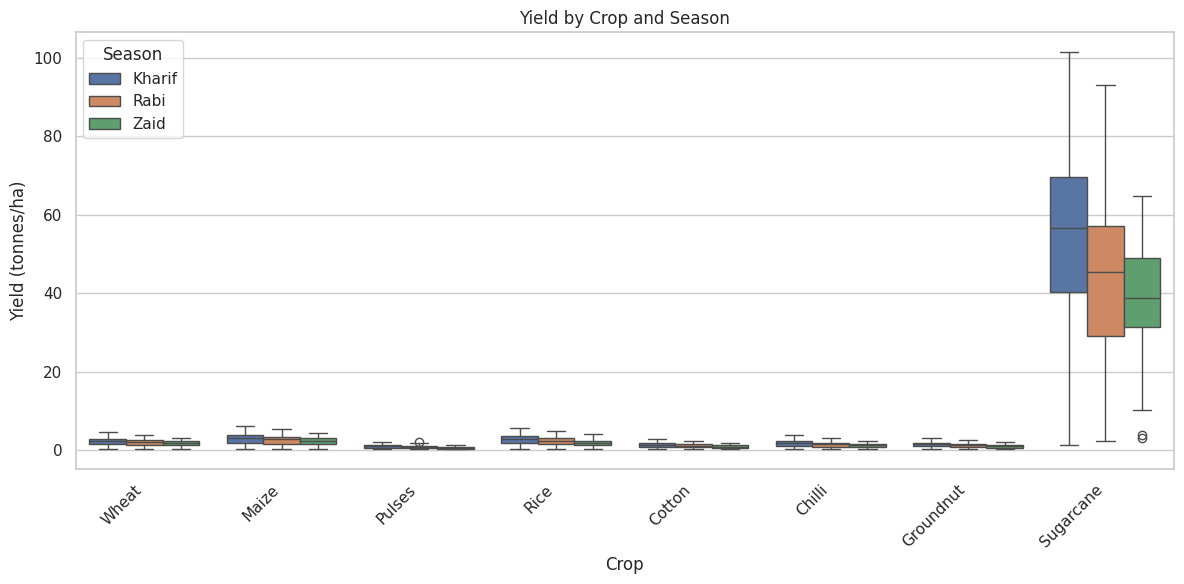

In [36]:
# Multivariate: Season, crop and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

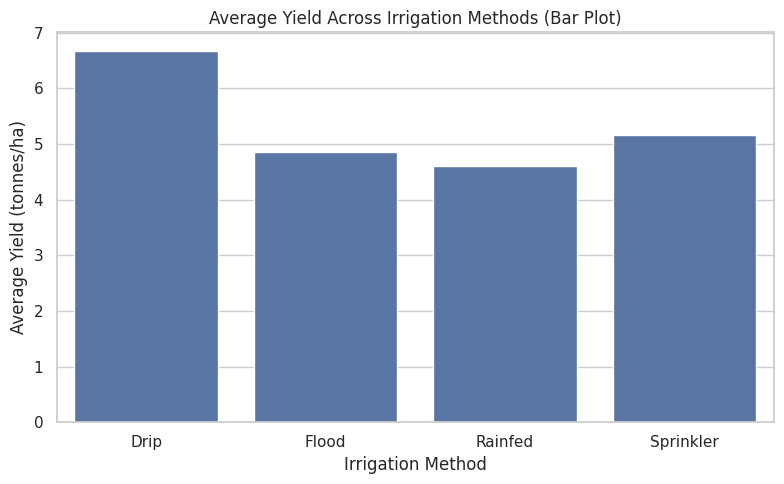

In [37]:
# Multivariate: Yield across irrigation methods

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

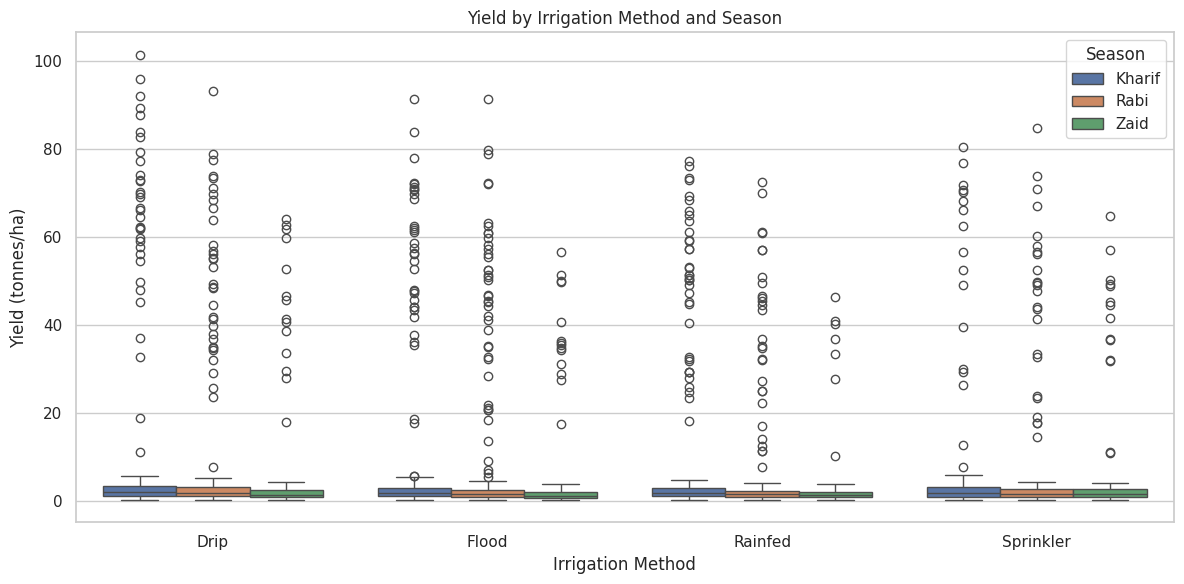

In [38]:
# Multivariate: Season, irrigation and yield

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

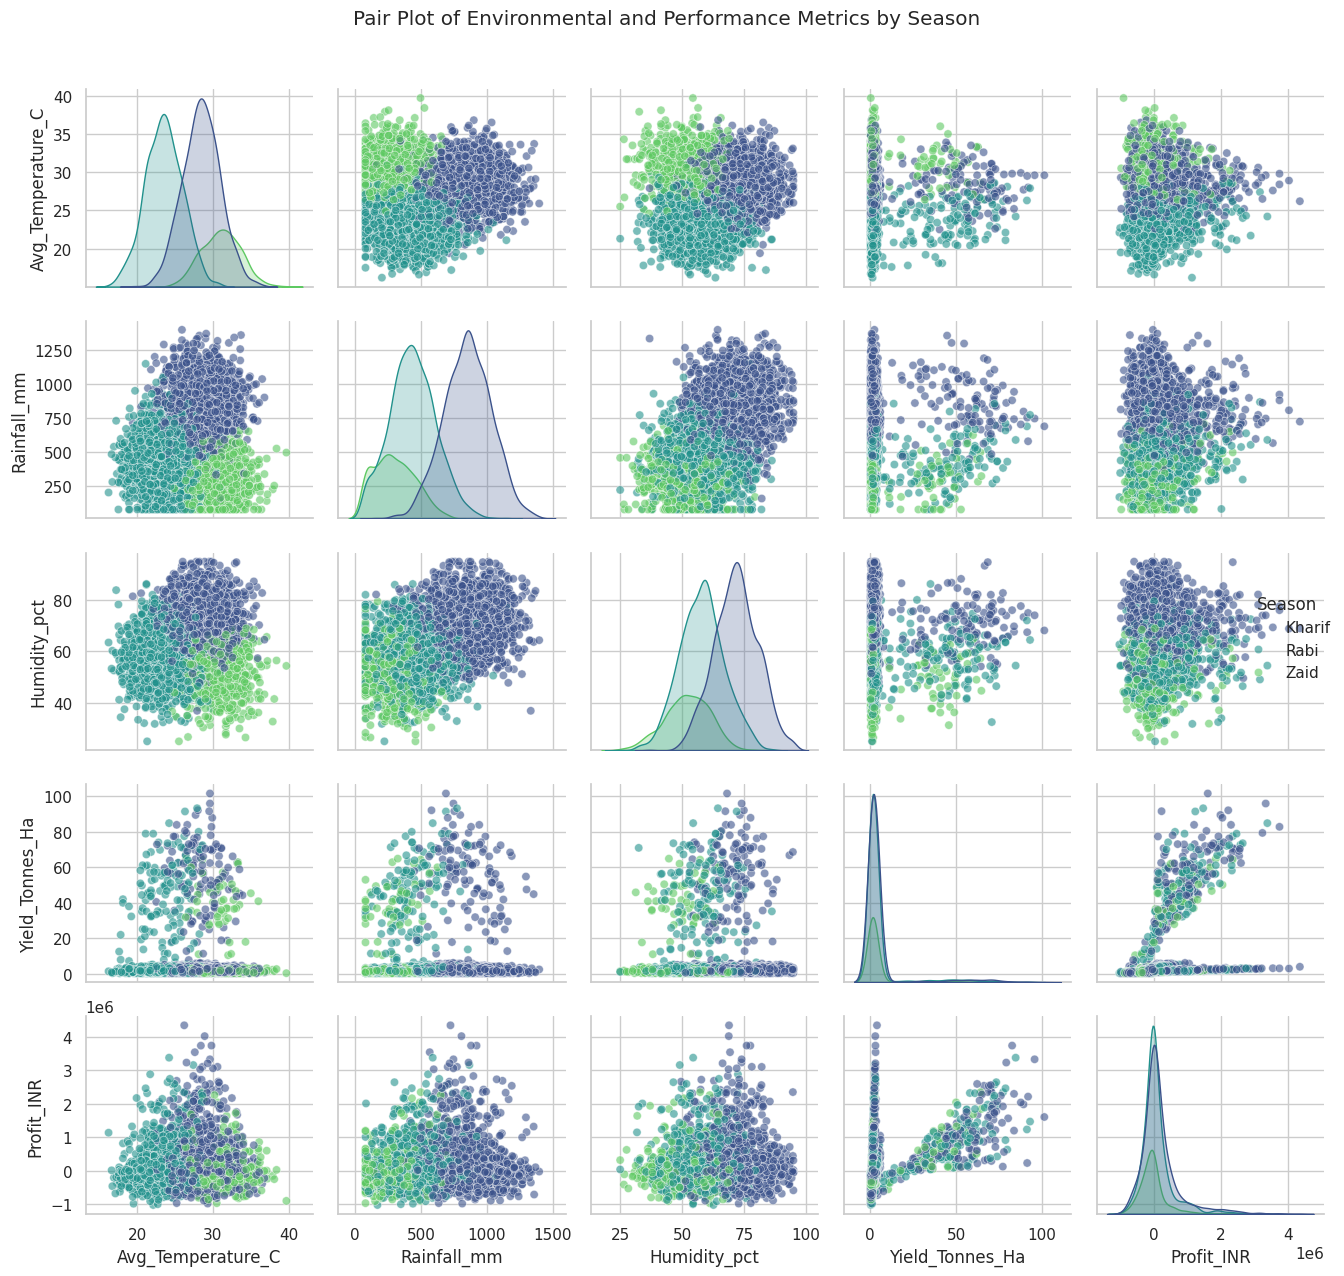

In [39]:
# Multivariate: Pair Plot of key environmental and performance metrics by season

selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02)
plt.tight_layout()
plt.show()

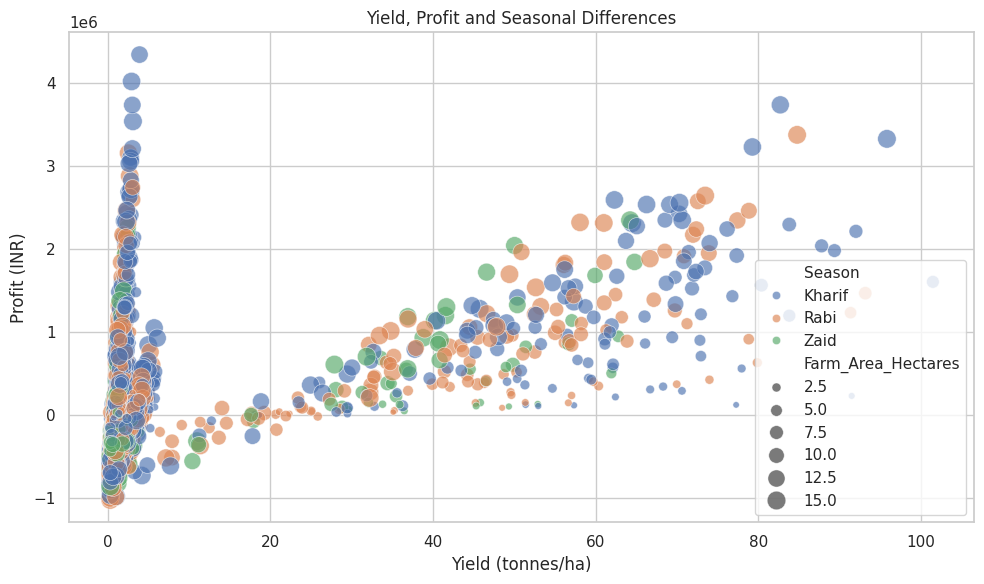

In [40]:
# Multivariate: Profit, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

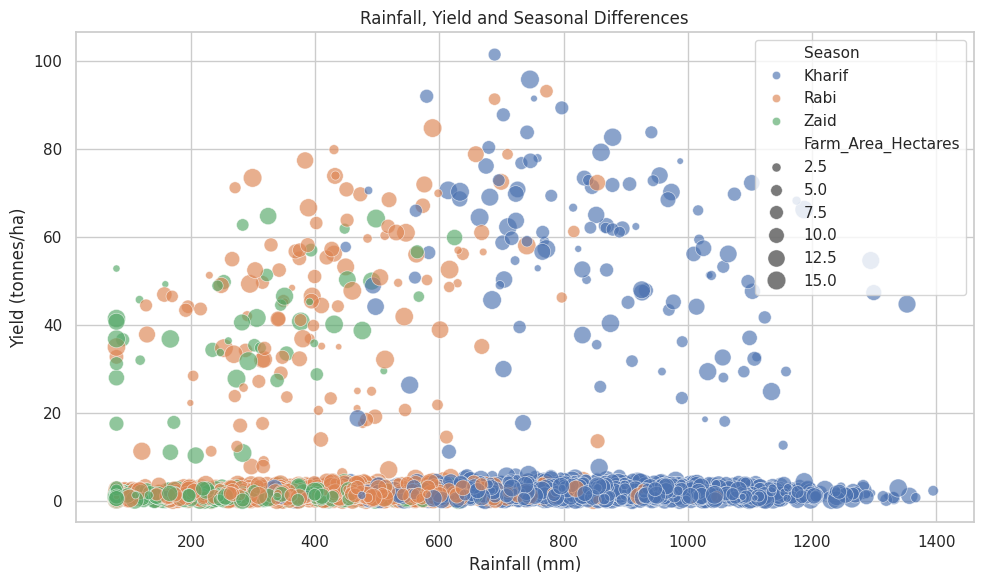

In [41]:
# Multivariate: Rainfall, yield and season (bubble plot)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

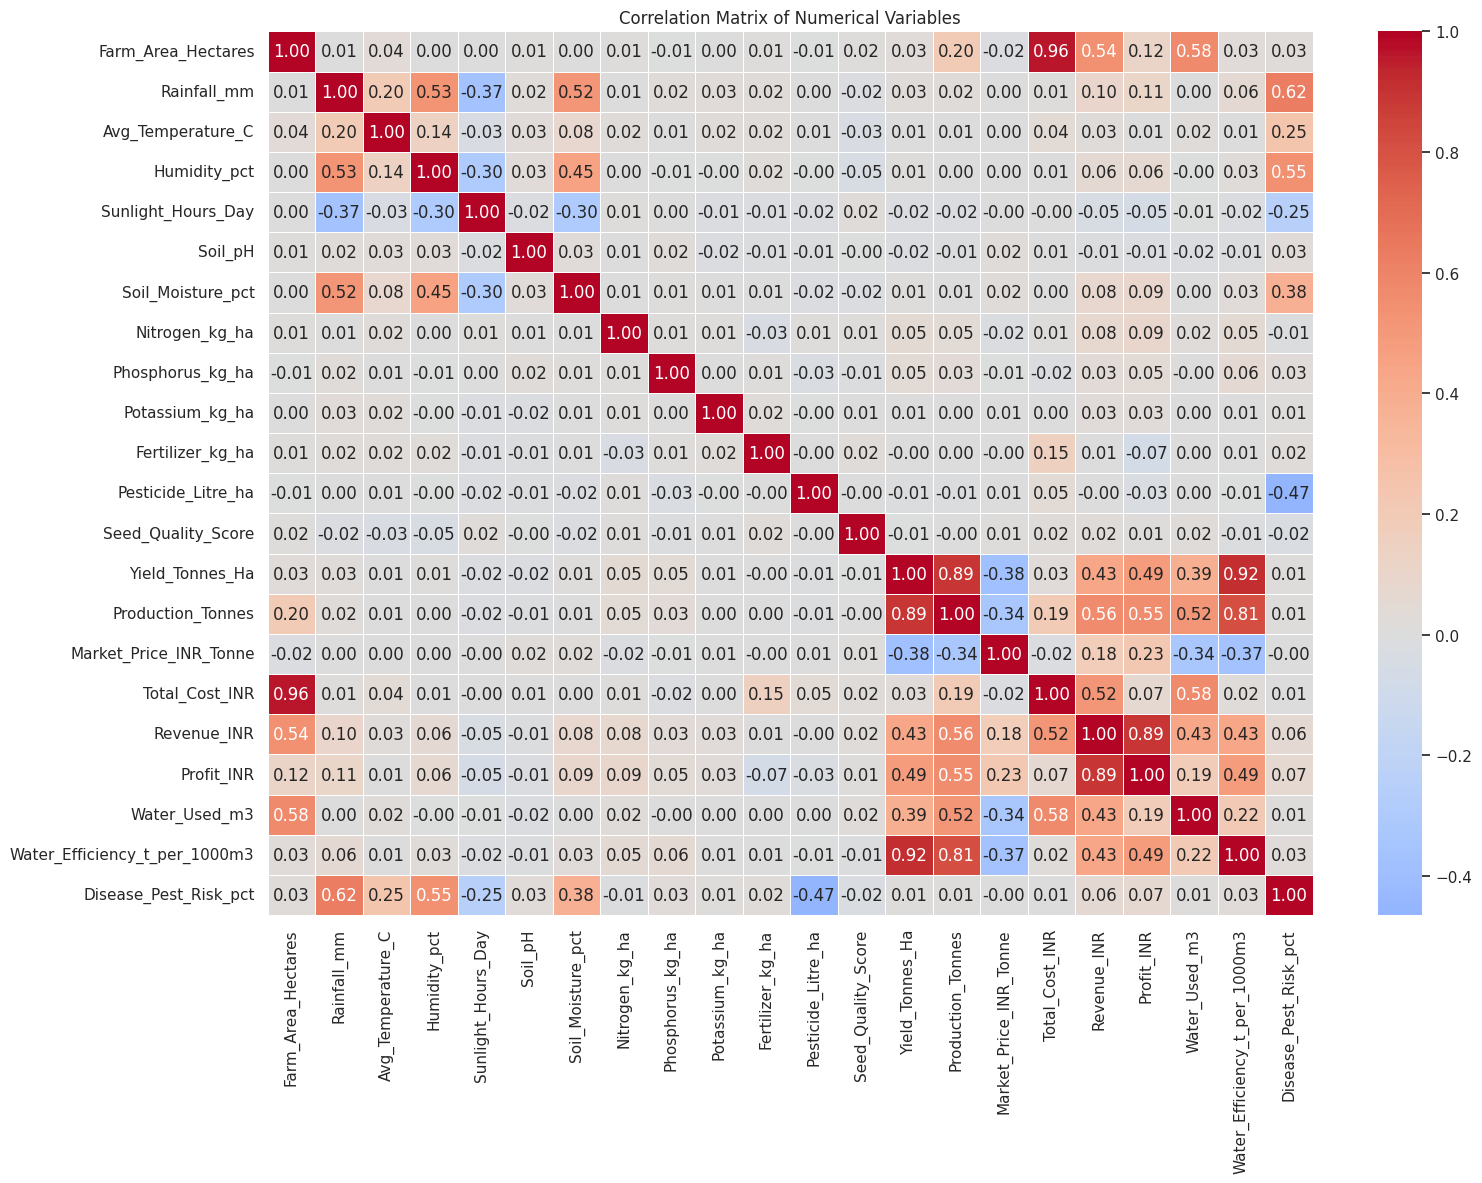

In [42]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

**Interpretation:**
- **Water_Efficiency_t_per_1000m3** has by far the strongest correlation with Yield (r ≈ 0.92), followed by Production_Tonnes (r ≈ 0.89) - both are close to definitionally linked to yield, so this is expected rather than a new discovery.
- Profit correlates most strongly with **Revenue_INR** (r ≈ 0.89) and only moderately with Yield itself (r ≈ 0.49), showing that yield alone is not the main profit driver - price and cost matter comparably.
- The season-crop view shows Sugarcane dominates yield and profit in every season, and Wheat, Maize and Rice lose money on average in every season (Pulses only in Rabi and Zaid). Crop mix does not explain Kharif's lead: Sugarcane is 7.0% of Kharif records but 8.6% of Zaid records, and Kharif beats Rabi and Zaid on yield and profit within all 8 crops (see Section 12).

## 12. Seasonal Comparison

Move from individual plots to structured comparisons. Compare seasons in summary tables and visualizations across meaningful measures. Not every variable needs to be compared; select the ones that help answer the project problem.

In [43]:
# General seasonal summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.09,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.63,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [44]:
from scipy import stats

def eta_squared(data, value, group):
    grand = data[value].mean()
    ss_between = data.groupby(group)[value].apply(lambda s: len(s) * (s.mean() - grand) ** 2).sum()
    ss_total = ((data[value] - grand) ** 2).sum()
    return ss_between / ss_total

# Share of the variance in yield and profit explained by each factor (in %)
variance_explained = (pd.DataFrame({
    value: {g: eta_squared(df, value, g) for g in ["Crop", "Season", "Irrigation_Method", "State"]}
    for value in ["Yield_Tonnes_Ha", "Profit_INR"]
}) * 100).round(1)
variance_explained.columns = ["Yield_variance_explained_%", "Profit_variance_explained_%"]
variance_explained

,Yield_variance_explained_%,Profit_variance_explained_%
Crop,80.70,35.00
Season,0.10,1.70
Irrigation_Method,0.40,1.20
State,0.10,0.10


In [45]:
seasons = ["Kharif", "Rabi", "Zaid"]
yield_cs = df.pivot_table(index="Crop", columns="Season", values="Yield_Tonnes_Ha", aggfunc="mean")[seasons].round(2)
profit_cs = df.pivot_table(index="Crop", columns="Season", values="Profit_INR", aggfunc="mean")[seasons].round(0)
season_test = pd.DataFrame({
    "Yield_Kharif>Rabi>Zaid": (yield_cs["Kharif"] > yield_cs["Rabi"]) & (yield_cs["Rabi"] > yield_cs["Zaid"]),
    "Profit_Kharif>Rabi>Zaid": (profit_cs["Kharif"] > profit_cs["Rabi"]) & (profit_cs["Rabi"] > profit_cs["Zaid"]),
    "Profit_KruskalWallis_p": {c: f"{stats.kruskal(*[g['Profit_INR'] for _, g in sub.groupby('Season')]).pvalue:.1e}"
                               for c, sub in df.groupby("Crop")}
})
season_test

,Yield_Kharif>Rabi>Zaid,Profit_Kharif>Rabi>Zaid,Profit_KruskalWallis_p
Chilli,True,True,9.7e-04
Cotton,True,True,2.1e-08
Groundnut,True,True,1.4e-05
Maize,True,True,6.1e-07
Pulses,True,True,3.1e-07
Rice,True,True,1.4e-08
Sugarcane,True,True,2.7e-03
Wheat,True,True,3.9e-04


In [46]:
# Crop-season summary: which crops perform best in which season

crop_season_summary = (
    df.groupby(["Season", "Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
    )
    .round(2)
    .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.71      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.95      731,612.86                     27.92
       Maize               2.62      -89,133.40                      5.46
       Rice                2.33      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.46      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.19      107,343.59                      1.94
       Pulses              0.87      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.28     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.18      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.94      -53,925.34                      1.49
       Pulses              0.65     -139,227.81                      1.95

**Variance explained and within-crop seasonal test:** Crop explains about 81% of yield variance and 35% of profit variance; season explains about 0.1% and 1.7%. Even so, Kharif > Rabi > Zaid holds for yield and profit in all 8 crops, and the profit difference between seasons is significant within every crop (Kruskal-Wallis, p < 0.01). The season effect is real but small next to crop choice.

**Comparison summary:**
Using the season-level table above (3-season averages):

| Season | Avg Yield (t/ha) | Avg Profit (₹) | Avg Water Efficiency (t/1000m³) |
|---|---|---|---|
| Kharif | 5.63 | 178,915 | 5.89 |
| Rabi | 5.09 | 87,689 | 5.19 |
| Zaid | 4.63 | **-24,805** | 4.41 |

**Kharif wins on all three measures** - highest yield, highest profit, and best water efficiency - so the picture is consistent rather than mixed. Zaid is the weakest season on every measure and is the only season with a **negative average profit**, and it also has the highest share of loss-making farms (64.5% of Zaid records report a loss, vs 42.2% in Kharif). This is consistent with Zaid having the lowest average rainfall (≈299 mm) and the highest average temperature (≈31°C) of the three seasons, making it the most resource-constrained growing window.

## 13. Additional Student-Driven Analysis

This section is intentionally open-ended.

Possible directions include:
- Regional differences
- Crop-specific seasonal patterns
- Resource usage
- Economic performance
- Environmental conditions
- Risk patterns
- Relationships discovered during exploration



                Records  Average_Yield  Average_Profit
State                                                 
Punjab              484           6.12      136,025.64
Maharashtra         512           5.01      135,428.86
Karnataka           489           5.75      119,422.34
Tamil Nadu          485           4.87      117,744.75
Gujarat             488           5.76      117,568.24
Telangana           516           5.05      108,829.62
Madhya Pradesh      497           4.98       86,840.76
Andhra Pradesh      529           4.63       73,453.53


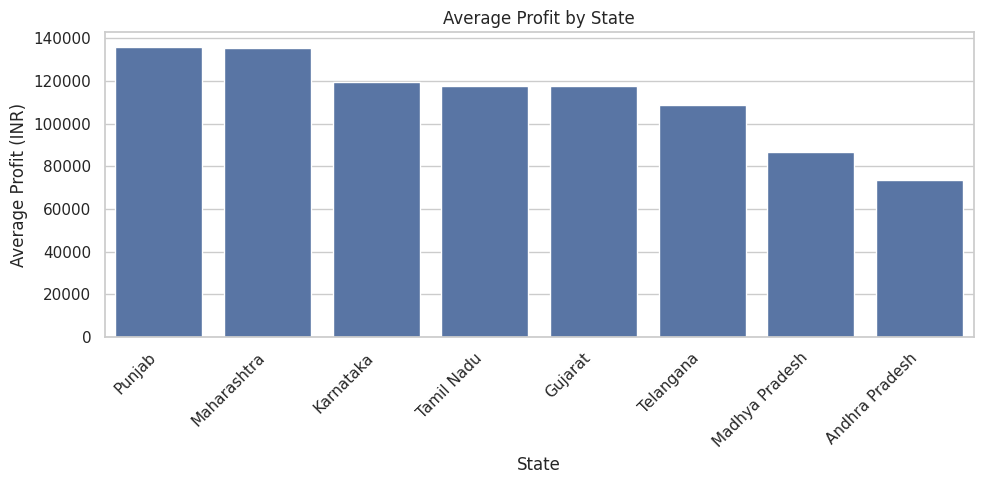

In [47]:
# Student Analysis 1
#
# Question: Which states perform best on profit and yield, and is regional performance
# consistent with the seasonal pattern found above?
# Analysis: Group by State and compare average yield and profit.

state_summary = df.groupby("State").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2).sort_values("Average_Profit", ascending=False)

print(state_summary)

plt.figure(figsize=(10, 5))
sns.barplot(x=state_summary.index, y=state_summary["Average_Profit"], order=state_summary.index)
plt.xticks(rotation=45, ha="right")
plt.title("Average Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

                   Average_Yield  Average_Water_Efficiency  Average_Water_Used
Irrigation_Method                                                             
Rainfed                     4.60                      7.56            3,549.55
Drip                        6.68                      6.27            5,918.75
Sprinkler                   5.16                      4.67            6,208.26
Flood                       4.86                      3.44            8,026.47


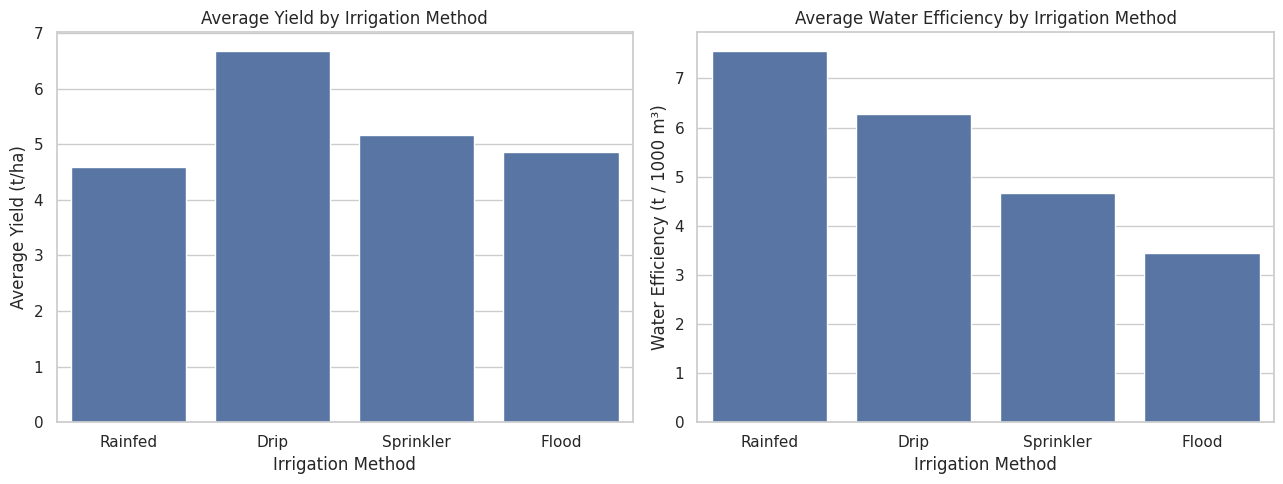

In [48]:
# Student Analysis 2
#
# Question: Does irrigation method explain differences in yield and water efficiency,
# independent of season?
# Analysis: Compare average yield and water efficiency across irrigation methods.

irrigation_summary = df.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2).sort_values("Average_Water_Efficiency", ascending=False)

print(irrigation_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=irrigation_summary.index, y=irrigation_summary["Average_Yield"], ax=axes[0])
axes[0].set_title("Average Yield by Irrigation Method")
axes[0].set_xlabel("Irrigation Method")
axes[0].set_ylabel("Average Yield (t/ha)")

sns.barplot(x=irrigation_summary.index, y=irrigation_summary["Average_Water_Efficiency"], ax=axes[1])
axes[1].set_title("Average Water Efficiency by Irrigation Method")
axes[1].set_xlabel("Irrigation Method")
axes[1].set_ylabel("Water Efficiency (t / 1000 m³)")
plt.tight_layout()
plt.show()

In [49]:
# Irrigation within crop: is Drip's yield lead only a crop-mix effect?
irr = df.pivot_table(index="Crop", columns="Irrigation_Method", values="Yield_Tonnes_Ha", aggfunc="mean").round(2)
print(irr)
print("Drip has the highest yield in", (irr.idxmax(axis=1) == "Drip").sum(), "of 8 crops")

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Crop                                              
Chilli             1.72   1.49     1.44       1.49
Cotton             1.42   1.17     1.11       1.25
Groundnut          1.31   1.36     1.28       1.31
Maize              2.81   2.78     2.49       2.82
Pulses             1.05   0.88     0.86       0.89
Rice               2.78   2.24     2.36       2.48
Sugarcane         54.87  46.87    40.53      44.37
Wheat              2.30   2.03     1.97       2.23
Drip has the highest yield in 6 of 8 crops


**Interpretation:** Rainfed has the highest water efficiency (7.56) because it uses the least water (3,550 m³ vs 8,026 m³ for Flood), not because it yields more (4.60 t/ha, the lowest). Drip has the highest average yield (6.68 t/ha) and leads within 6 of 8 crops.

        Average_Disease_Pest_Risk  Pct_Farms_With_Loss
Season                                                
Kharif                      54.47                42.21
Rabi                        40.48                51.14
Zaid                        38.22                64.48


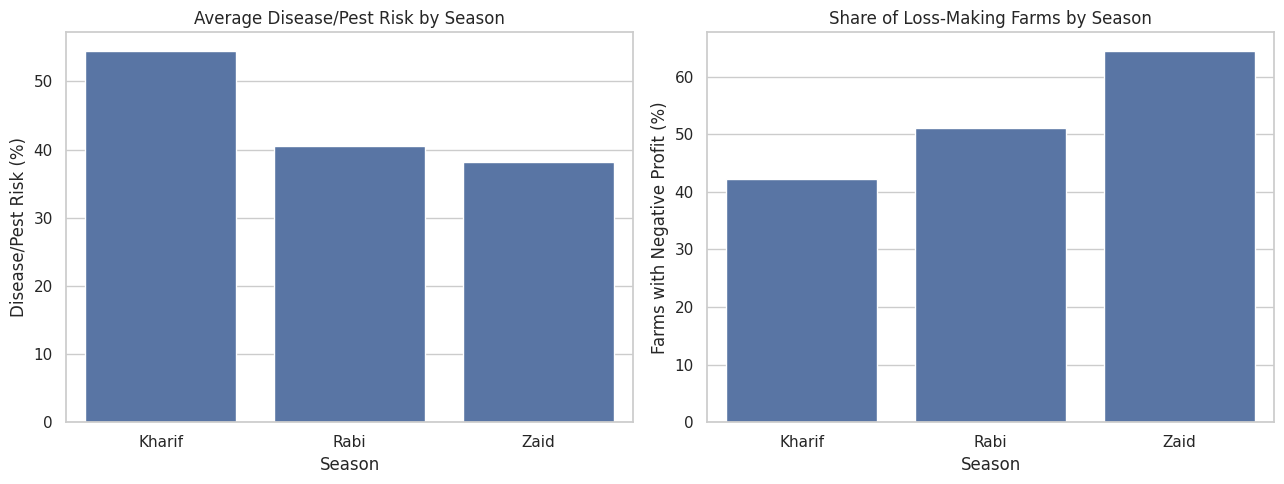

In [50]:
# Student Analysis 3
#
# Question: Does disease/pest risk vary by season, and does it help explain why Zaid
# performs worst economically?
# Analysis: Compare average Disease_Pest_Risk_pct and the share of loss-making farms by season.

risk_summary = df.groupby("Season").agg(
    Average_Disease_Pest_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)
risk_summary["Pct_Farms_With_Loss"] = df.groupby("Season").apply(
    lambda x: round((x["Profit_INR"] < 0).mean() * 100, 2), include_groups=False
)

print(risk_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=risk_summary.index, y=risk_summary["Average_Disease_Pest_Risk"], ax=axes[0])
axes[0].set_title("Average Disease/Pest Risk by Season")
axes[0].set_ylabel("Disease/Pest Risk (%)")

sns.barplot(x=risk_summary.index, y=risk_summary["Pct_Farms_With_Loss"], ax=axes[1])
axes[1].set_title("Share of Loss-Making Farms by Season")
axes[1].set_ylabel("Farms with Negative Profit (%)")
plt.tight_layout()
plt.show()

## 14. Key Insights

Write **at least 8 meaningful insights** from the analysis.

For each insight, follow this structure:
1. **Observation** – What did you observe?
2. **Evidence** – Which analysis supports it?
3. **Interpretation** – What does the evidence indicate?
4. **Limitation** – What should not be assumed from the finding?

Avoid statements that claim causation when the analysis only shows association.

**Insight 1 - Kharif is the strongest season overall**
- Observation: Kharif has the highest average yield (5.63 t/ha), highest average profit (₹1.79 lakh) and best water efficiency (5.89 t/1000m³) of the three seasons.
- Evidence: Section 12 seasonal summary table and within-crop seasonal test.
- Interpretation: Kharif's monsoon-driven rainfall (≈852 mm average) appears to support stronger overall farm performance than the other two seasons. The order Kharif > Rabi > Zaid holds for both yield and profit within all 8 crops, and the profit difference between seasons is significant within each crop (Kruskal-Wallis, p < 0.01).
- Limitation: This is an association across seasons, not a controlled experiment. Crop mix is similar across seasons (Sugarcane is 7.0% of Kharif and 8.6% of Zaid records), so it does not explain the gap, but rainfall cannot be separated from other season-specific differences such as temperature and soil moisture.

**Insight 2 - Zaid is the only season with a net loss**
- Observation: Zaid's average profit is **-₹24,805**, and 64.5% of Zaid farm records report a loss, compared to 42.2% in Kharif and 51.1% in Rabi.
- Evidence: Section 12 season summary and Student Analysis 3.
- Interpretation: Zaid combines the lowest average rainfall (≈299 mm) and highest average temperature (≈31°C) of the three seasons, both consistent with harsher growing conditions.
- Limitation: Disease/pest risk is actually *lowest* in Zaid (38.2% vs 54.5% in Kharif), so disease pressure does not explain Zaid's poor economics. Zaid coincides with the lowest rainfall and highest temperature, but this data cannot show which factor, if any, drives the loss.

**Insight 3 - Crop explains far more of yield than season does**
- Observation: Sugarcane yields 38-53 t/ha depending on season, while every other crop averages under 3 t/ha in every season.
- Evidence: Crop-season summary table and variance-explained table (Section 12).
- Interpretation: Crop explains about 81% of yield variance versus about 0.1% for season, so any season-only yield comparison is heavily influenced by the Sugarcane records. Season still matters within a crop: Kharif > Rabi > Zaid yield holds in all 8 crops.
- Limitation: The dataset does not indicate whether Sugarcane's seasonal label reflects agronomic reality or planting/reporting convention for a multi-season crop, so this needs care in interpretation.

**Insight 4 - Wheat, Maize and Rice lose money in every season**
- Observation: Wheat, Maize and Rice show *negative* average profit in Kharif, Rabi and Zaid alike (e.g. Wheat: -₹1.06 lakh in Kharif, -₹1.20 lakh in Rabi, -₹1.93 lakh in Zaid). Pulses is positive in Kharif (+₹43,339) and negative in Rabi and Zaid.
- Evidence: Crop-season profit summary (Section 12).
- Interpretation: The overall positive average profit in the dataset is being carried almost entirely by high-value crops (Sugarcane, Chilli, Cotton), not by staple grains.
- Limitation: Profit here reflects the recorded cost/revenue figures only; it does not capture subsidies, MSP support or non-market value of staple crops to the farmer.

**Insight 5 - Drip gives the highest yield; Rainfed is the most water-efficient**
- Observation: Drip has the highest average yield (6.68 t/ha) and second-highest water efficiency (6.27 t/1000m³). Rainfed has the highest water efficiency (7.56) while using the least water (3,550 m³ average). Flood has the lowest water efficiency (3.44) and uses the most water (8,026 m³ average).
- Evidence: Student Analysis 2.
- Interpretation: Drip's yield lead holds within 6 of 8 crops, so it is not only a crop-mix effect. Rainfed's water efficiency reflects low water use, not high yield (its average yield of 4.60 t/ha is the lowest).
- Limitation: Irrigation method is not randomly assigned - farms using drip may also differ in other ways (soil quality, farmer investment capacity), so this is an association, not proof that switching method alone would produce the same gain. Irrigation method explains under 1% of overall yield variance, so the differences are modest.

**Insight 6 - Water efficiency and production are the strongest numeric correlates of yield**
- Observation: `Water_Efficiency_t_per_1000m3` (r ≈ 0.92) and `Production_Tonnes` (r ≈ 0.89) show the strongest correlation with yield (both are calculated from yield, so this is expected); nutrient variables (Nitrogen, Phosphorus) show almost no linear correlation (r < 0.06).
- Evidence: Correlation heatmap (Section 11).
- Interpretation: In this dataset, water-related efficiency tracks yield closely, while the fertilizer variables recorded do not show a simple linear relationship with yield at the whole-dataset level.
- Limitation: Correlation coefficients only capture linear relationships; nutrient effects may be threshold-based or interact with crop type in ways a single correlation number would miss.

**Insight 7 - Profit is driven more by revenue than by yield alone**
- Observation: Profit correlates far more strongly with Revenue (r ≈ 0.89) than with Yield (r ≈ 0.49).
- Evidence: Correlation heatmap (Section 11).
- Interpretation: Market price and cost structure matter at least as much as physical yield in determining whether a farm record is profitable.
- Limitation: The dataset provides a single `Market_Price_INR_Tonne` per record rather than a time series, so price volatility over a season cannot be examined here.

**Insight 8 - Punjab and Maharashtra lead on profit; Andhra Pradesh lags**
- Observation: Punjab (₹1.36 lakh avg profit) and Maharashtra (₹1.35 lakh) are the top-performing states, while Andhra Pradesh (₹0.73 lakh) is the lowest of the eight states covered.
- Evidence: Student Analysis 1 (state-wise summary).
- Interpretation: Regional differences in profit are large enough to be a second axis of variation alongside season, worth investigating alongside seasonal planning.
- Limitation: State-level averages mix different crops and irrigation methods per state, so this reflects the overall regional mix rather than a pure "location effect."

## 15. Recommendations

Provide evidence-based recommendations that:
- Clearly connect to an observed finding.
- Avoid unsupported assumptions.
- Acknowledge important limitations.
- Focus on what the data can reasonably support.

1. **Prioritize Kharif-aligned planning where feasible.** Since Kharif shows the highest yield, profit and water efficiency of the three seasons, farmers and cooperatives should treat it as the primary planning window and examine why Zaid underperforms before expanding Zaid-season cultivation. *(Ties to Insight 1 & 2.)*

2. **Re-evaluate Zaid-season crop and resource choices.** Given Zaid's negative average profit and 64.5% loss rate, cooperatives should investigate lower-risk crop or irrigation choices specifically for Zaid rather than applying the same practices used in Kharif/Rabi. Disease/pest risk is not the driver (it's lowest in Zaid), so rainfall-scarcity and heat-tolerant practices are the areas to test. *(Ties to Insight 2.)*

3. **Always compare yield/profit within crop, not just within season.** Because Sugarcane's yield scale dwarfs every other crop, any seasonal performance report should present crop-controlled comparisons (as in Section 12) rather than blended season averages, to avoid misleading conclusions. *(Ties to Insight 3 & 4.)*

4. **Support wider adoption of drip irrigation, especially for water-scarce seasons.** Drip shows the highest yield and the second-highest water efficiency after Rainfed; expanding drip access - particularly for Zaid, which already has the lowest rainfall - could improve both yield and water use. *(Ties to Insight 5.)*

5. **Treat grain-crop economics as a separate policy question from yield improvement.** Since Wheat, Maize and Rice run at a loss in every season in this dataset (Pulses in Rabi and Zaid), recommendations aimed at raising farmer income for these crops should focus on cost and price (procurement price, input cost support) rather than yield alone, since yield is not the binding constraint on their profitability here. *(Ties to Insight 4 & 7.)*

6. **Do not assume this is causal.** All recommendations above are based on observed associations in a single cross-sectional dataset; before acting on them at scale, they should be validated with controlled trials or multi-year data, since factors like farmer skill, soil quality and local market access are not separated out in this data.

## 16. Conclusion

Summarize:
- What the dataset revealed about seasonal agricultural performance.
- The most important patterns discovered.
- The most useful analytical findings.
- Important limitations of the analysis.
- How the analysis could support future investigation or decision-making.

This analysis of 4,000 farm records across 3 seasons, 8 states and 8 crops shows that seasonal agricultural performance in this dataset is **not uniform**: Kharif consistently leads on yield, profit and water efficiency, while Zaid is the weakest season and the only one with a net average loss. However, the most important discovery is that **season alone is not the dominant driver of yield or profit - crop choice is**, although the Kharif > Rabi > Zaid order holds within every crop. Sugarcane's yield is an order of magnitude above every other crop in every season, and Wheat, Maize and Rice run at a loss in all three seasons, meaning the dataset's positive overall averages are carried almost entirely by a few high-value crops.

Water efficiency and production show the strongest numerical relationship with yield, but both are calculated from yield. Among irrigation methods, Drip has the highest yield and Rainfed the highest water efficiency, but irrigation explains under 1% of overall yield variance, so the differences are modest. Profit, meanwhile, tracks revenue more closely than it tracks yield, underlining that price and cost - not just physical output - determine whether a farm record is profitable.

**Key limitations:** this is a single cross-sectional dataset (not a multi-year panel), so the analysis shows associations and seasonal snapshots, not causal effects; state, crop and irrigation method are not randomly assigned across records, so regional and practice-based differences are confounded with unmeasured factors like soil quality and farmer capacity.

**Future direction:** the findings here support prioritizing crop-controlled and irrigation-method-controlled comparisons in any seasonal agricultural planning, and point to Zaid-season resource-scarcity and grain-crop cost structure as the two areas most worth a deeper, targeted follow-up study.